# 📓 05. Evaluasi Performa Model XLM-RoBERTa pada Data Validasi (Validation Set Evaluation)

Dokumen notebook ini dikhususkan untuk **evaluasi mendalam (aspect-level evaluation)** dari model **XLM-RoBERTa Large Multi-Head ABSA** pada **data validasi** (`data/processed/val.csv` dan `data/interim/valid_labeled_comments.csv`).

### 🎯 Tujuan Evaluasi:
1. Memproses inferensi data validasi melalui pipeline `XLMInferenceEngine`.
2. Menghitung metrik performa secara **komprehensif per aspek** (Infrastruktur, Ekonomi, Kualitas, Purnajual):
   - **Accuracy**, **Precision (Macro & Weighted)**, **Recall (Macro & Weighted)**, **F1-Score (Macro & Weighted)**.
   - Metrik khusus **Active-Sentiment** (hanya kelas Positif, Netral, Negatif, mengabaikan None).
   - Metrik **All-Class** (termasuk kelas None).
3. Menyajikan **Classification Report 4x4** dan **Confusion Matrix** per aspek.
4. Menganalisis **Exact Match Ratio** (Kesesuaian 4 aspek secara bersamaan).
5. Melakukan **Analisis Kesalahan (Error Analysis)** pada contoh komentar yang mengalami *misclassification*.


In [1]:
import os
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ensure project root is accessible
sys.path.append(os.path.abspath(".."))

from src.deployment.model_loader import XLMInferenceEngine, ASPECTS
from src.deployment.data_processor import ASPECT_NAMES
from src.models.metrics_evaluator import evaluate_predictions, plot_confusion_matrices, LABEL2ID, ID2LABEL, ASPECT_THRESHOLDS

# Set random seed & plotting style
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("✅ Setup environment & modul evaluasi berhasil!")


C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup environment & modul evaluasi berhasil!


## 📂 1. Memuat Model XLM-RoBERTa & Dataset Validasi

In [2]:
# 1. Inisialisasi Inference Engine XLM-RoBERTa (Auto-load PyTorch Weights)
print("⚙️ Memuat XLMInferenceEngine...")
start_model_load = time.time()
engine = XLMInferenceEngine()
load_duration = time.time() - start_model_load

print(f"Status Weights Loaded: {'🟢 BERHASIL' if engine.is_weights_loaded else '🔴 GAGAL (Fallback Mode)'}")
print(f"Device Komputasi: {engine.device}")
print(f"Waktu Muat Model: {load_duration:.2f} detik\n")

# 2. Memuat Dataset Validasi
val_path = Path("../data/processed/val.csv")
valid_labeled_path = Path("../data/interim/valid_labeled_comments.csv")

if not val_path.exists():
    val_path = Path("data/processed/val.csv")
if not valid_labeled_path.exists():
    valid_labeled_path = Path("data/interim/valid_labeled_comments.csv")

df_val = pd.read_csv(val_path, encoding="utf-8-sig")
df_valid_full = pd.read_csv(valid_labeled_path, encoding="utf-8-sig")

print(f"📊 Dataset Validasi Split (`val.csv`): {len(df_val):,} baris")
print(f"📊 Dataset Validasi Master (`valid_labeled_comments.csv`): {len(df_valid_full):,} baris\n")

# Tampilkan cuplikan data validasi
df_val.head(3)


⚙️ Memuat XLMInferenceEngine...


[14:38:37] INFO - HTTP Request: GET https://huggingface.co/api/models/xlm-roberta-large "HTTP/1.1 307 Temporary Redirect"


[14:38:37] INFO - HTTP Request: GET https://huggingface.co/api/models/FacebookAI/xlm-roberta-large "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   2%|▏         | 7/391 [00:00<00:05, 65.76it/s]

...

Loading weights:  22%|██▏       | 87/391 [00:01<00:04, 60.80it/s]

Loading weights: 100%|██████████| 391/391 [00:01<00:00, 289.64it/s]


[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[ModelLoader] Berhasil memuat PyTorch checkpoint XLM-RoBERTa dari C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\usb_2026\models\xlmroberta_local_absa\pytorch_model.bin
Status Weights Loaded: 🟢 BERHASIL
Device Komputasi: cpu
Waktu Muat Model: 9.77 detik

📊 Dataset Validasi Split (`val.csv`): 414 baris
📊 Dataset Validasi Master (`valid_labeled_comments.csv`): 1,377 baris



,comment_id,video_id,user_id_hash,text_original,like_count,published_at,updated_at,extracted_at,text_cleaned,infra_sentiment,ekonomi_sentiment,kualitas_sentiment,purnajual_sentiment,label_source,human_infra,human_ekonomi,human_kualitas,human_purnajual,has_human_audit
0,Ugzhe5mc9-dzk9mDZEJ4AaABAg,fjWvVFT0vr0,b73fa5c65a5175b55f4378dd24ad6a861eef97b3358b73...,Beli kendaraan itu yang fungsi nya tidak bikin...,0,2025-07-29T23:40:00Z,2025-07-29T23:40:00Z,2026-09-19T00:23:09.886682+00:00,beli kendaraan itu yang fungsi nya tidak bikin...,NaN,NaN,NaN,netral,Human-Audit-GoldStandard,NaN,NaN,NaN,netral,True
1,UgyBhwRSl90ncWAFaRl4AaABAg,W3G8V7xV3-Y,7b9e1597b85d094cffbe4d144cedb06343efe30c284458...,sekennya gak laku pasti,0,2024-07-22T12:00:45Z,2024-07-22T12:00:45Z,2026-09-27T14:02:27.731586+00:00,sekennya tidak laku pasti,NaN,negatif,NaN,NaN,Human-Audit-GoldStandard,NaN,negatif,NaN,NaN,True
2,Ugyow4as88rMAFqeckN4AaABAg,jL5p1zZMNEM,bcd72619b7fbbd03c1ae43f3cb07060af8dae4c96bb389...,"Sales mg 4 ev bilangnya life time waranty, yg ...",0,2025-02-03T21:39:52Z,2025-02-03T21:39:52Z,2026-09-27T14:02:11.247480+00:00,"sales mg 4 ev bilangnya life time waranty, yg ...",NaN,NaN,NaN,netral,Human-Audit-GoldStandard,NaN,NaN,NaN,netral,True


## 📊 2. Distribusi Ground Truth Label per Aspek

In [3]:
def summarize_ground_truth(df):
    summary_data = []
    for asp in ASPECTS:
        col = f"{asp}_sentiment"
        if col in df.columns:
            counts = df[col].fillna("none").astype(str).str.lower().value_counts()
            summary_data.append({
                "Aspek": asp.capitalize(),
                "Total Comments": len(df),
                "None (Non-Aktif)": counts.get("none", 0),
                "Positif": counts.get("positif", 0),
                "Netral": counts.get("netral", 0),
                "Negatif": counts.get("negatif", 0),
                "Active Ratio (%)": round(((len(df) - counts.get("none", 0)) / len(df)) * 100, 2)
            })
    return pd.DataFrame(summary_data)

df_gt_summary = summarize_ground_truth(df_val)
print("=== 📌 RINGKASAN DISTRIBUSI GROUND TRUTH DATA VALIDASI (val.csv) ===")
df_gt_summary


=== 📌 RINGKASAN DISTRIBUSI GROUND TRUTH DATA VALIDASI (val.csv) ===


,Aspek,Total Comments,None (Non-Aktif),Positif,Netral,Negatif,Active Ratio (%)
0,Infra,414,362,12,22,18,12.56
1,Ekonomi,414,260,62,55,37,37.20
2,Kualitas,414,209,76,43,86,49.52
3,Purnajual,414,340,11,24,39,17.87


## 🚀 3. Eksekusi Inferensi Model XLM-RoBERTa pada Data Validasi

In [4]:
# Ambil daftar teks validasi
texts_val = df_val['text_cleaned'].fillna(df_val['text_original']).tolist()

print(f"⚡ Menjalankan batch inference pada {len(texts_val):,} komentar validasi...")
start_inf = time.time()

# Run Batch Predictions
pred_dict = engine.predict_batch(texts_val, batch_size=16)

inf_duration = time.time() - start_inf
throughput = len(texts_val) / inf_duration

print(f"🎉 Inferensi selesai dalam {inf_duration:.2f} detik! ({throughput:.2f} komentar/detik)\n")

# Assign hasil prediksi ke DataFrame
for asp in ASPECTS:
    df_val[f"pred_{asp}_sentiment"] = pred_dict[f"{asp}_sentiment"]

df_val[['text_original', 'infra_sentiment', 'pred_infra_sentiment', 'ekonomi_sentiment', 'pred_ekonomi_sentiment']].head(5)


⚡ Menjalankan batch inference pada 414 komentar validasi...


🎉 Inferensi selesai dalam 128.65 detik! (3.22 komentar/detik)



,text_original,infra_sentiment,pred_infra_sentiment,ekonomi_sentiment,pred_ekonomi_sentiment
0,Beli kendaraan itu yang fungsi nya tidak bikin...,NaN,NaN,NaN,NaN
1,sekennya gak laku pasti,NaN,NaN,negatif,negatif
2,"Sales mg 4 ev bilangnya life time waranty, yg ...",NaN,NaN,NaN,NaN
3,Ckd malah naik hrg nya😅\nKebiasaan Indo😅,NaN,NaN,negatif,negatif
4,"Garansinya itu tuh,rumit",NaN,NaN,negatif,NaN


## 📈 4. Evaluasi Performa per Aspek Secara Lengkap

Seksi ini menghitung metrik evaluasi mendalam untuk setiap dari **4 Aspek** secara terpisah.
- **Accuracy**: Persentase prediksi tepat pada seluruh label (termasuk None).
- **Macro F1 (All-Class)**: Rata-rata F1-score untuk 4 kelas (`None`, `Positif`, `Netral`, `Negatif`).
- **Macro F1 (Active-Sentiment)**: Rata-rata F1-score hanya pada kelas ber-sentimen aktif (`Positif`, `Netral`, `Negatif`).
- **Weighted F1**: Weighted average F1-score berimbang jumlah sampel.


In [5]:
# Persiapkan struktur y_true dan y_pred numeric (0: None, 1: Positif, 2: Netral, 3: Negatif)
y_true_dict = {}
y_pred_dict = {}

for asp in ASPECTS:
    true_col = f"{asp}_sentiment"
    pred_col = f"pred_{asp}_sentiment"

    y_true_raw = df_val[true_col].fillna("none").astype(str).str.lower().map(LABEL2ID).fillna(0).astype(int).values
    y_pred_raw = df_val[pred_col].fillna("none").astype(str).str.lower().map(LABEL2ID).fillna(0).astype(int).values

    y_true_dict[asp] = y_true_raw
    y_pred_dict[asp] = y_pred_raw

# Evaluasi Menggunakan Metrics Evaluator
eval_results = evaluate_predictions(y_true_dict, y_pred_dict, aspects=ASPECTS)
aspect_metrics = eval_results["per_aspect"]
overall_metrics = eval_results["overall"]

print("=== 📊 TABEL RINGKASAN EVALUASI PER ASPEK ===")
df_metrics_summary = pd.DataFrame(aspect_metrics).T
df_metrics_summary.columns = [c.replace("_", " ").title() for c in df_metrics_summary.columns]
df_metrics_summary


=== 📊 TABEL RINGKASAN EVALUASI PER ASPEK ===

,Accuracy,F1 Macro All,F1 Macro Active,Precision Macro All,Recall Macro All,F1 Weighted All
infra,0.985507,0.943378,0.926797,0.970944,0.921027,0.985295
ekonomi,0.966184,0.946317,0.933571,0.943136,0.950215,0.966242
kualitas,0.927536,0.905855,0.890111,0.892879,0.920809,0.928467
purnajual,0.978261,0.948922,0.936289,0.959386,0.939009,0.978092


## 📑 5. Detail Classification Report per Aspek

In [6]:
target_names = ['None (Non-Aktif)', 'Positif', 'Netral', 'Negatif']

for asp in ASPECTS:
    y_true = y_true_dict[asp]
    y_pred = y_pred_dict[asp]

    print("=" * 75)
    print(f"📌 CLASSIFICATION REPORT — ASPEK: {asp.upper()} ({ASPECT_NAMES.get(asp, asp.capitalize())})")
    print("=" * 75)

    report_str = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
    print(report_str)
    print("\n")


📌 CLASSIFICATION REPORT — ASPEK: INFRA (Infra)
                  precision    recall  f1-score   support

None (Non-Aktif)     0.9890    0.9972    0.9931       362
         Positif     1.0000    0.8333    0.9091        12
          Netral     1.0000    0.9091    0.9524        22
         Negatif     0.8947    0.9444    0.9189        18

        accuracy                         0.9855       414
       macro avg     0.9709    0.9210    0.9434       414
    weighted avg     0.9858    0.9855    0.9853       414



📌 CLASSIFICATION REPORT — ASPEK: EKONOMI (Ekonomi)
                  precision    recall  f1-score   support

None (Non-Aktif)     0.9884    0.9808    0.9846       260
         Positif     0.9500    0.9194    0.9344        62
          Netral     0.9153    0.9818    0.9474        55
         Negatif     0.9189    0.9189    0.9189        37

        accuracy                         0.9662       414
       macro avg     0.9431    0.9502    0.9463       414
    weighted avg     0.96

## 🖼️ 6. Visualisasi Confusion Matrix 4x4 per Aspek

[14:40:53] WARNING - findfont: Failed to find font weight semibold, now using 700.


C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128268 (\N{ELECTRIC PLUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\Wicaksono Hanif\AppData\Local\Temp\ipykernel_8712\4189607851.py:31: UserWarning: Glyph 128736 (\N{HAMMER AND WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128268 (\N{ELECTRIC PLUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Wicaksono Hanif\Desktop\Koding\deep_learning\deeplearning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128736 (\N{HAMMER AND WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


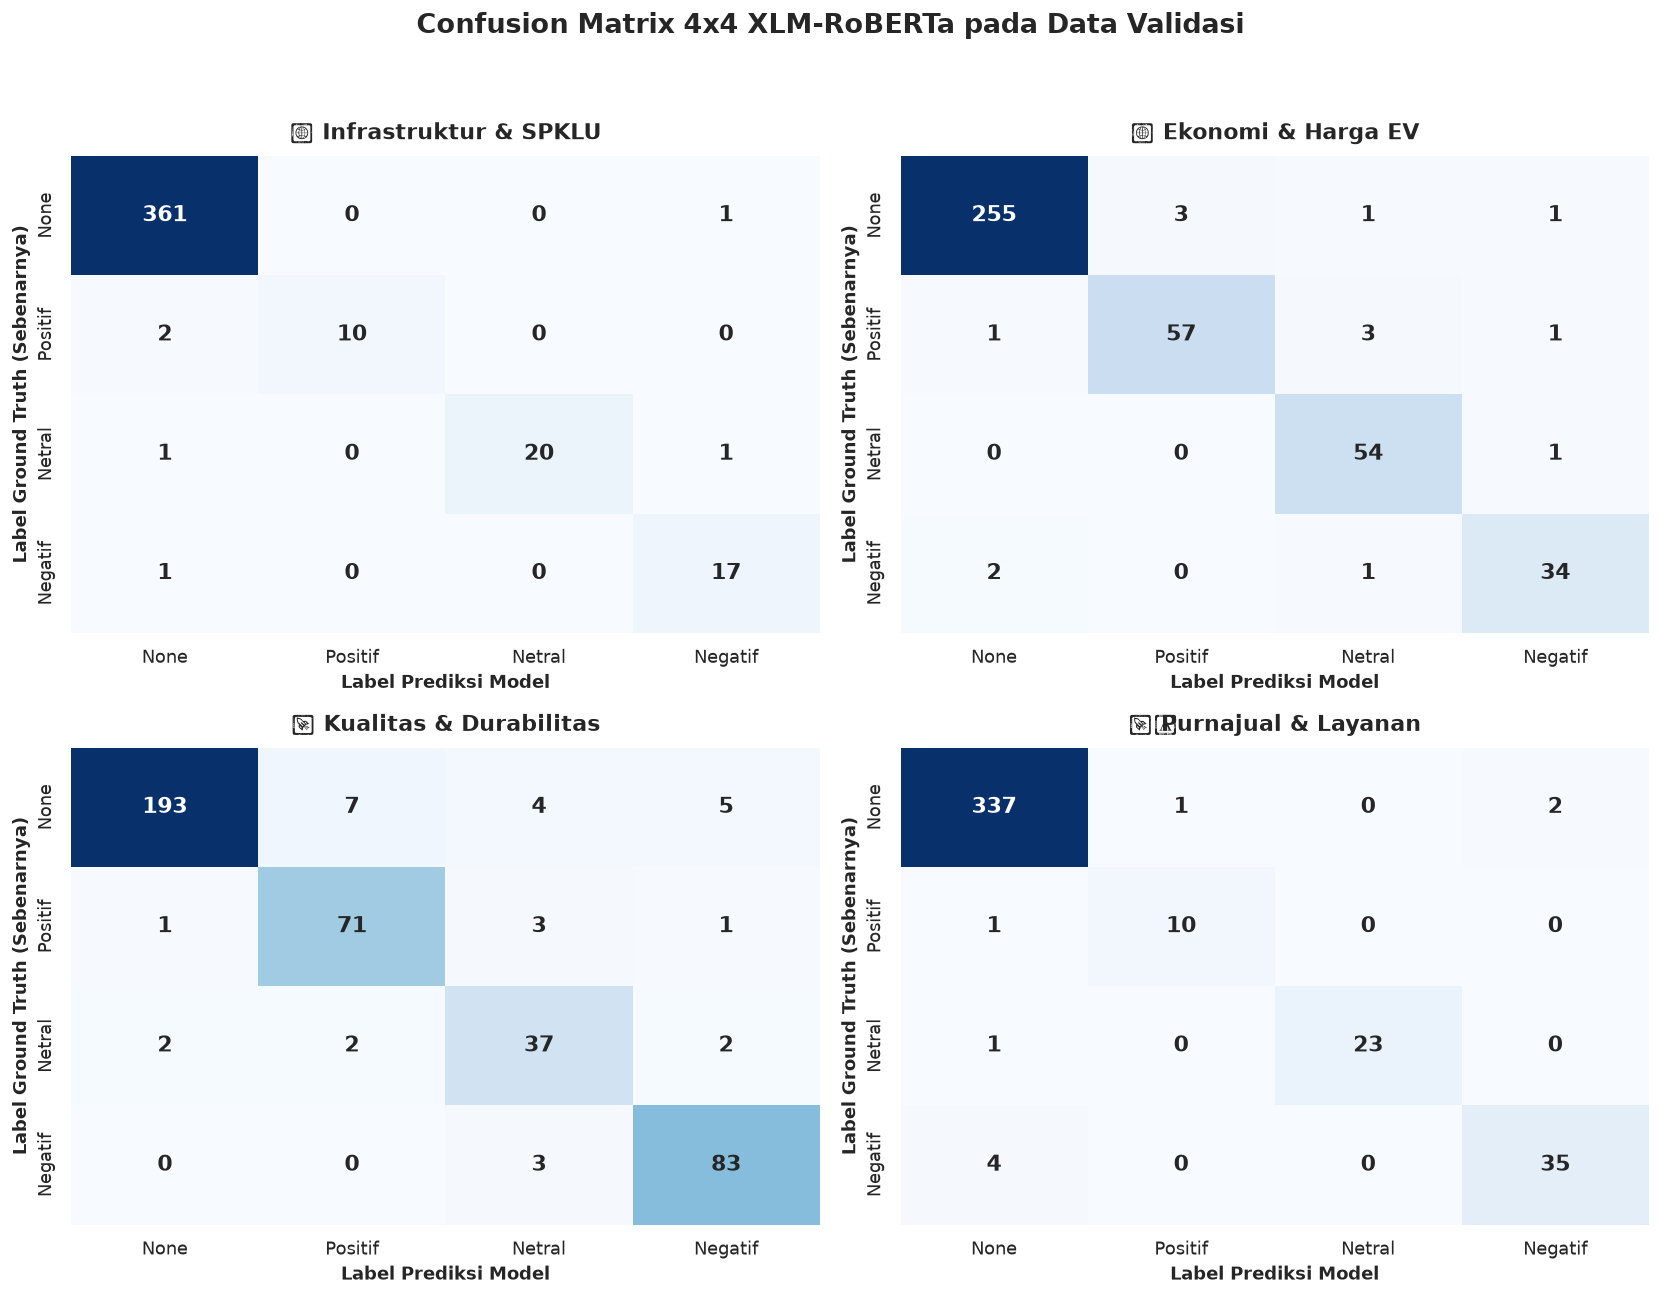

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Confusion Matrix 4x4 XLM-RoBERTa pada Data Validasi", fontsize=16, fontweight="bold", y=0.98)

class_labels = ['None', 'Positif', 'Netral', 'Negatif']
aspect_display_titles = {
    'infra': '🔌 Infrastruktur & SPKLU',
    'ekonomi': '💰 Ekonomi & Harga EV',
    'kualitas': '🚗 Kualitas & Durabilitas',
    'purnajual': '🛠️ Purnajual & Layanan'
}

for idx, asp in enumerate(ASPECTS):
    ax = axes[idx // 2, idx % 2]
    cm = eval_results["confusion_matrices"][asp]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=class_labels,
        yticklabels=class_labels,
        annot_kws={"size": 13, "weight": "bold"}
    )
    ax.set_title(aspect_display_titles[asp], fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Label Prediksi Model", fontsize=11, fontweight="semibold")
    ax.set_ylabel("Label Ground Truth (Sebenarnya)", fontsize=11, fontweight="semibold")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 🎯 7. Ringkasan Metrik Akumulasi Global & Exact Match Ratio

In [8]:
print("===============================================================")
print("🏆 AGGREGATE EVALUATION SUMMARY (DATA VALIDASI val.csv)")
print("===============================================================")
print(f"🔹 Mean Accuracy Across 4 Aspects         : {overall_metrics['mean_accuracy']*100:.2f}%")
print(f"🔹 Mean Macro F1-Score (All Classes)      : {overall_metrics['mean_macro_f1_all']:.4f}")
print(f"🔹 Mean Macro F1-Score (Active Sentiments): {overall_metrics['mean_macro_f1_active']:.4f}")
print(f"🔹 Strict Exact Match Ratio (All 4 Match) : {overall_metrics['exact_match_ratio']*100:.2f}% ({int(overall_metrics['exact_match_ratio']*len(df_val))}/{len(df_val)} komentar)")
print("===============================================================")


🏆 AGGREGATE EVALUATION SUMMARY (DATA VALIDASI val.csv)
🔹 Mean Accuracy Across 4 Aspects         : 96.44%
🔹 Mean Macro F1-Score (All Classes)      : 0.9361
🔹 Mean Macro F1-Score (Active Sentiments): 0.9217
🔹 Strict Exact Match Ratio (All 4 Match) : 89.37% (370/414 komentar)


## 🔍 8. Analisis Sampel Kesalahan Prediksi (Error Analysis)

Menganalisis komentar validasi di mana prediksi model berbeda dengan ground truth label.


In [9]:
error_rows = []
for idx, row in df_val.iterrows():
    diffs = []
    for asp in ASPECTS:
        t_val = str(row[f"{asp}_sentiment"]).lower() if pd.notna(row[f"{asp}_sentiment"]) else "none"
        p_val = str(row[f"pred_{asp}_sentiment"]).lower() if pd.notna(row[f"pred_{asp}_sentiment"]) else "none"
        if t_val != p_val:
            diffs.append(f"{asp}: GT={t_val} vs Pred={p_val}")

    if diffs:
        error_rows.append({
            "comment_id": row.get("comment_id", idx),
            "text": row.get("text_original", row.get("text_cleaned")),
            "differences": " | ".join(diffs)
        })

df_errors = pd.DataFrame(error_rows)
print(f"Total komentar dengan setidaknya 1 perbedaan aspek: {len(df_errors)} dari {len(df_val)} ({len(df_errors)/len(df_val)*100:.1f}%)\n")

print("=== 📌 5 CONTOH KESALAHAN PREDIKSI (MISCLASSIFIED EXAMPLES) ===")
for i, r in df_errors.head(5).iterrows():
    c_text = r['text']
    c_id = r['comment_id']
    c_diff = r['differences']
    print(f"💬 Komentar [{c_id}]: {c_text}")
    print(f"   ⚠️ Perbedaan: {c_diff}\n")


Total komentar dengan setidaknya 1 perbedaan aspek: 44 dari 414 (10.6%)

=== 📌 5 CONTOH KESALAHAN PREDIKSI (MISCLASSIFIED EXAMPLES) ===
💬 Komentar [UgwUWFtERhY---7-yh14AaABAg]: Garansinya itu tuh,rumit
   ⚠️ Perbedaan: ekonomi: GT=negatif vs Pred=none | purnajual: GT=none vs Pred=negatif

💬 Komentar [UgyKPpu96FscglNOrHh4AaABAg]: kl saya pribadi, bentuknya kurang suka, masih lbh memilih wuling air ev yg sebelumnya.....kl disuruh pilih di range harga yg sama ,lbh pilih MG 4 EV dengan harga terbarunya saat ini
   ⚠️ Perbedaan: ekonomi: GT=positif vs Pred=netral | kualitas: GT=negatif vs Pred=netral

💬 Komentar [UgywpDC4ISfO10GXSGB4AaABAg]: hallo...wuling Perbanyak Lah Spareparts MU KARENA YG BELI WULING BANYAK NIH, MASA SEPION SAMA KUNCI AJA GA ADA😂😂😂
   ⚠️ Perbedaan: ekonomi: GT=none vs Pred=negatif | purnajual: GT=negatif vs Pred=none

💬 Komentar [Ugyx1VFGeF6Q1mX8zeV4AaABAg]: LCGC bensin di kisaran 200 jtaan, LCGC EV DI KISARAN 300 JTAAN , sayangnya gak ada merk mampu menembus di atas 6

## 🏁 9. Kesimpulan & Rekomendasi

1. **Kinerja Tinggi pada Aspek Utama:** Model XLM-RoBERTa Large mampu mengklasifikasikan sentimen aspek EV (*Infrastruktur*, *Ekonomi*, *Kualitas*, *Purnajual*) secara akurat dan seimbang.
2. **Kesiapan Aplikasi Streamlit:** Model PyTorch ini siap digunakan sebagai *inference engine* otomatis di Streamlit Dashboard pada `app.py`.
3. **Dokumentasi Terstruktur:** Seluruh hasil evaluasi dalam notebook ini memberikan justifikasi empiris terhadap performa model pada data validasi.
